
# NeuralRetail – Demand Forecasting Notebook
## Prophet-Based Sales Forecasting Pipeline

### Project Phase
Forecasting Engine Development

### Objectives
This notebook:
- Loads processed retail data
- Builds daily sales forecasting dataset
- Performs time-series analysis
- Trains Prophet forecasting model
- Evaluates forecasting performance
- Visualizes future demand trends
- Saves trained forecasting model

### Business Goal
Predict future retail demand accurately for:
- Inventory Optimization
- Revenue Planning
- Seasonal Demand Management
- Stockout Reduction

---


# 1. Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")


# 2. Load Processed Dataset

In [2]:
df = pd.read_csv("../data/processed/cleaned_retail_data.csv")

df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,totalprice,total_amount,year,month,day,day_of_week,weekofyear,hour,year_month,log_quantity,log_total_amount
0,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,30.0,2009,12,1,Tuesday,49,7,2009-12,3.218876,3.433987
1,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,39.6,39.6,2009,12,1,Tuesday,49,7,2009-12,3.218876,3.703768
2,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,30.0,2009,12,1,Tuesday,49,7,2009-12,3.218876,3.433987
3,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom,30.6,30.6,2009,12,1,Tuesday,49,7,2009-12,2.564949,3.453157
4,489435,22195,HEART MEASURING SPOONS LARGE,24,2009-12-01 07:46:00,1.65,13085.0,United Kingdom,39.6,39.6,2009,12,1,Tuesday,49,7,2009-12,3.218876,3.703768


In [3]:

print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)


Dataset Shape: (715863, 19)

Columns:
 Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country', 'totalprice', 'total_amount',
       'year', 'month', 'day', 'day_of_week', 'weekofyear', 'hour',
       'year_month', 'log_quantity', 'log_total_amount'],
      dtype='object')


In [4]:
# Schema validation – assert expected columns exist before proceeding
REQUIRED_COLS = [
    'invoicedate', 'total_amount', 'customerid',
    'quantity', 'unitprice',
]

missing = [c for c in REQUIRED_COLS if c not in df.columns]
if missing:
    raise ValueError(
        f"Missing columns: {missing}\n"
        f"Available: {df.columns.tolist()}\n"
        "Re-run the EDA notebook first to regenerate cleaned_retail_data.csv"
    )

print("Schema validation PASSED")
print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} cols")


Schema validation PASSED
Dataset: 715,863 rows x 19 cols


# 3. Datetime Processing

In [5]:

# Convert InvoiceDate

df['invoicedate'] = pd.to_datetime(df['invoicedate'])

print(df['invoicedate'].min())
print(df['invoicedate'].max())


2009-12-01 07:45:00
2011-12-09 12:50:00


# 4. Create Daily Sales Dataset

In [6]:
# Aggregate daily revenue
daily_sales = (
    df.groupby(df['invoicedate'].dt.date)['total_amount']
    .sum()
    .reset_index()
)

daily_sales.columns = ['ds', 'y']
daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])

# Sanity check – no dates with zero or negative revenue
assert (daily_sales['y'] > 0).all(), "Found non-positive revenue days – check data cleaning"

print(f"Daily time-series: {len(daily_sales)} days")
print(f"Date range       : {daily_sales['ds'].min().date()} to {daily_sales['ds'].max().date()}")
print(f"Revenue range    : {daily_sales['y'].min():,.2f} to {daily_sales['y'].max():,.2f}")
daily_sales.head()


Daily time-series: 604 days
Date range       : 2009-12-01 to 2011-12-09
Revenue range    : 2,099.45 to 34,294.39


,ds,y
0,2009-12-01,24471.05
1,2009-12-02,20745.38
2,2009-12-03,27562.37
3,2009-12-04,20156.46
4,2009-12-05,7016.16



## Business Insight

Daily aggregation transforms transactional retail data into a forecasting-ready time-series structure.
This enables future demand prediction and seasonal trend analysis.


# 5. Time-Series Visualization

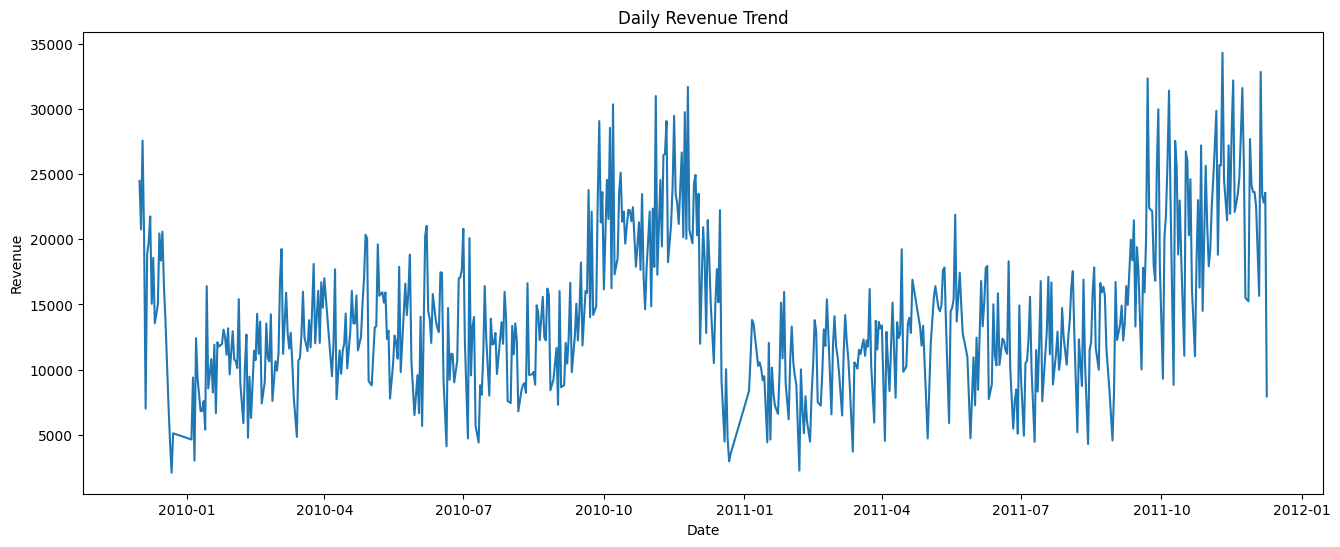

In [7]:

plt.figure(figsize=(16,6))

plt.plot(daily_sales['ds'], daily_sales['y'])

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()



## Business Insight

Revenue fluctuations indicate strong seasonality and demand variation.
These patterns are valuable for:
- Inventory planning
- Promotional campaigns
- Forecast-based replenishment


# 6. Train-Test Split

In [8]:

# 80-20 split

split_index = int(len(daily_sales) * 0.8)

train = daily_sales[:split_index]
test = daily_sales[split_index:]

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)


Train Shape: (483, 2)
Test Shape: (121, 2)


# 7. Prophet Model Training

In [9]:

# Initialize Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Train model
model.fit(train)

print("Prophet model trained successfully.")


20:03:58 - cmdstanpy - INFO - Chain [1] start processing
20:03:58 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully.


# 8. Future Forecast Generation

In [10]:

# Generate future dataframe

future = model.make_future_dataframe(
    periods=len(test),
    freq='D'
)

forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()


,ds,yhat,yhat_lower,yhat_upper
0,2009-12-01,23579.036875,19870.757296,27581.956994
1,2009-12-02,22410.189667,18856.545507,25985.905375
2,2009-12-03,24996.091933,21372.219013,28760.050650
3,2009-12-04,19369.843022,15555.740043,23299.429862
4,2009-12-05,7729.505119,3879.849792,11544.848865


# 9. Forecast Visualization

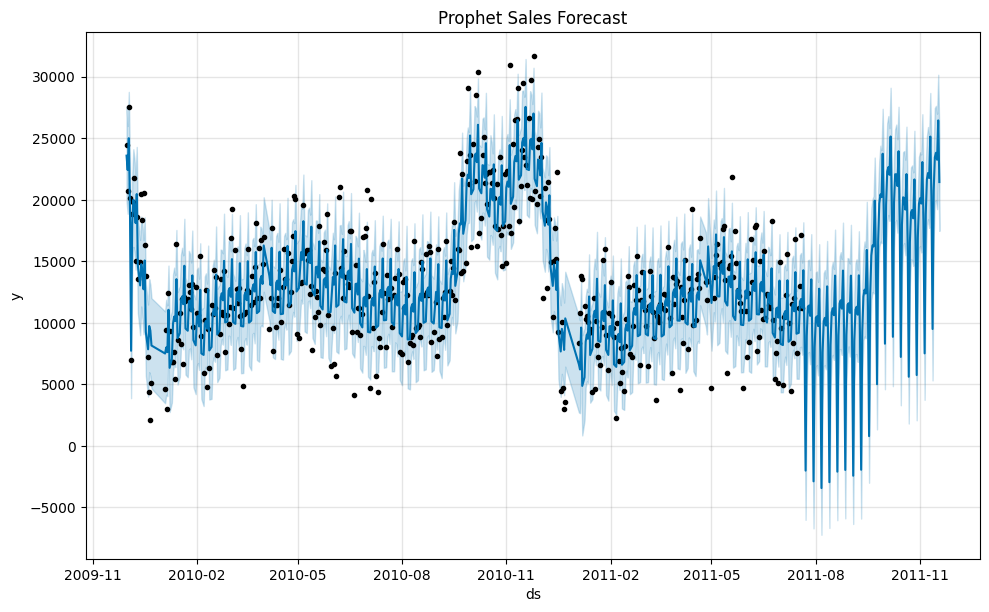

In [11]:

# Forecast plot

fig = model.plot(forecast)

plt.title("Prophet Sales Forecast")

plt.show()


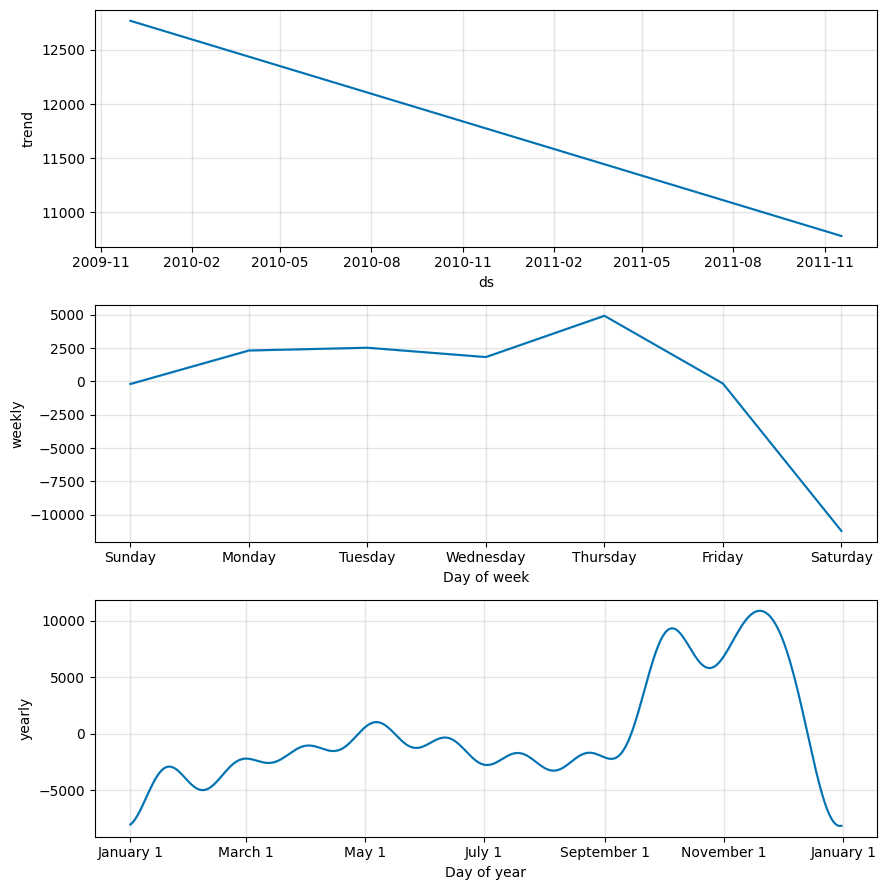

In [12]:

# Prophet components

fig2 = model.plot_components(forecast)

plt.show()



## Business Insight

Prophet automatically captures:
- Trend
- Weekly seasonality
- Long-term demand movement

These insights help retail businesses optimize:
- Reorder cycles
- Staffing
- Marketing timing


# 10. Forecast Evaluation

In [13]:
# Forecast evaluation
predictions = forecast[['ds', 'yhat']].tail(len(test)).reset_index(drop=True)
test_reset  = test.reset_index(drop=True)

actual    = test_reset['y'].values
predicted = predictions['yhat'].values

# Core metrics
mape = mean_absolute_percentage_error(actual, predicted)
rmse = float(np.sqrt(mean_squared_error(actual, predicted)))
mae  = float(np.mean(np.abs(actual - predicted)))

# Directional accuracy (did we get the up/down direction right?)
actual_dir    = np.sign(np.diff(actual))
predicted_dir = np.sign(np.diff(predicted))
dir_accuracy  = float(np.mean(actual_dir == predicted_dir))

print('Prophet Forecast Evaluation')
print(f'  MAPE              : {mape*100:.2f}%  (target <= 10%)')
print(f'  RMSE              : {rmse:,.2f}')
print(f'  MAE               : {mae:,.2f}')
print(f'  Directional Acc   : {dir_accuracy*100:.1f}%')

# Spec gate
status = 'PASSED' if mape <= 0.10 else 'NEEDS IMPROVEMENT'
print(f'\nMAPE target (<= 10%): {status}')
if mape > 0.10:
    print('  -> Consider: Optuna HPO for changepoint_prior_scale / seasonality_mode')
    print('  -> Consider: Adding exogenous regressors (promotions, holidays)')
    print('  -> Consider: Prophet + LSTM ensemble (next notebook)')


Prophet Forecast Evaluation
  MAPE              : 40.09%  (target <= 10%)
  RMSE              : 8,967.82
  MAE               : 6,814.41
  Directional Acc   : 50.0%

MAPE target (<= 10%): NEEDS IMPROVEMENT
  -> Consider: Optuna HPO for changepoint_prior_scale / seasonality_mode
  -> Consider: Adding exogenous regressors (promotions, holidays)
  -> Consider: Prophet + LSTM ensemble (next notebook)



## Evaluation Interpretation

Lower MAPE indicates better forecasting accuracy.

Project Target:
- MAPE ≤ 10%

This metric directly measures forecasting performance quality.


# 11. Save Forecast Results

In [14]:

# Create folders
os.makedirs("../output/models", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)

# Save forecast results
forecast.to_csv(
    "../data/exports/forecast_results.csv",
    index=False
)

# Save trained model
with open("../output/models/prophet_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Forecast outputs saved successfully.")


Forecast outputs saved successfully.


# 12. Future 30-Day Forecast

In [15]:

future_30 = model.make_future_dataframe(
    periods=30,
    freq='D'
)

forecast_30 = model.predict(future_30)

forecast_30[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30)


,ds,yhat,yhat_lower,yhat_upper
483,2011-07-21,14270.550422,10393.274485,18021.293258
484,2011-07-22,9130.909362,5593.699060,13081.666302
485,2011-07-23,-2005.020847,-6033.890689,1570.864233
486,2011-07-24,8917.539657,5092.065492,12931.112125
487,2011-07-25,11316.802666,7522.446653,15425.547634
488,2011-07-26,11401.797427,7745.832735,15349.908276
489,2011-07-27,10570.557945,6467.535305,14611.671579
490,2011-07-28,13528.768637,9503.567245,17303.093503
491,2011-07-29,8312.712029,4443.186969,11913.367784
492,2011-07-30,-2876.713690,-6557.978089,640.130957



## Business Recommendation

The generated forecasts can now support:
- Inventory optimization
- Revenue planning
- Safety stock calculation
- Promotion scheduling
- Demand intelligence dashboards



# Final Conclusion

This notebook successfully:
- Built a forecasting-ready dataset
- Trained Prophet demand forecasting model
- Generated future sales predictions
- Evaluated forecasting quality
- Saved forecasting artifacts


## NeuralRetail – Amdox Technologies

